In [9]:
import pandas as pd
import re
import numpy as np

# =========================================================
# 베드-날짜(bed_date) 기준 통계 산출 (다변수 + CV 포함)
# - groupby: bed_date
# - 대상 변수: area_cm2, conf, brightness_mean, blur_score,
#            perimeter_px, circularity, solidity, concavity, curvature, roughness
# - 통계: mean, std, min, max, cv(std/mean)
# - 결과: 컬럼을 모두 펼쳐서(변수_통계) 엑셀로 저장
# =========================================================

# ====== 0) 입력/출력 경로 ======
# (1) 사용자가 준 엑셀(원본 시트) 기준으로 진행
in_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/1파트(251128-251213)/251212_lettuce_segmentation_area(1)_index.xlsx"
sheet_name = "Sheet1"

out_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/1파트(251128-251213)/251212_lettuce index_statical.xlsx"

# 선택: cam 필터(필요 없으면 None)
CAM_FILTER = "cam0"   # 예: "cam0" 또는 None

# ====== 1) 로드 ======
df = pd.read_excel(in_path, sheet_name=sheet_name)

# ====== 2) filename에서 bed/date/time/cam/slot 파싱 ======
# 예: bed03_20251207_153012_cam0_00.png
pat = re.compile(
    r"^bed(?P<bed>\d{2})_(?P<date>\d{8})_(?P<time>\d{6})_(?P<cam>cam\d)_(?P<slot>\d{2})\.(png|jpg|jpeg)$",
    re.IGNORECASE
)

parsed = df["filename"].astype(str).str.extract(pat)
df = pd.concat([df, parsed], axis=1)

# 파싱 실패 확인
bad = df[df["bed"].isna() | df["date"].isna() | df["cam"].isna()]
if len(bad) > 0:
    print(f"[경고] 파일명 파싱 실패 행: {len(bad)}개 (패턴 불일치 가능)")

# 선택: cam 필터
if CAM_FILTER is not None:
    df = df[df["cam"].str.lower() == str(CAM_FILTER).lower()].copy()

# ====== 3) 집계 대상 컬럼 ======
metrics = [
    "area_px",
    "perimeter_px",
    "area_cm2",
    "conf",
    "brightness_mean",
    "blur_score",
    "perimeter_px",
    "circularity",
    "solidity",
    "concavity",
    "curvature",
    "roughness",
]

missing = [c for c in metrics if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 엑셀에 없습니다: {missing}")

# 숫자 변환(문자 들어있으면 NaN 될 수 있음)
for c in metrics:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ====== 4) bed_date로 그룹 묶어서 통계 산출 ======
g = df.groupby("bed_date", dropna=False)[metrics]

# 기본 통계
base = g.agg(["mean", "std", "min", "max"])  # MultiIndex columns

# CV = std/mean (mean이 0이면 NaN)
means = g.mean()
stds = g.std()
cv = stds.divide(means.replace({0: np.nan}))
cv.columns = pd.MultiIndex.from_product([cv.columns, ["cv"]])

# 합치기
agg = pd.concat([base, cv], axis=1)

# 컬럼 펼치기: (metric, stat) -> metric_stat
agg.columns = [f"{m}_{s}" for (m, s) in agg.columns]

# 부가정보: bed/date 분리(정렬용)
# bed_date = bed00_YYYYMMDD
agg = agg.reset_index()
agg["bed"] = agg["bed_date"].str.extract(r"^bed(\d{2})").astype(int)
agg["date"] = agg["bed_date"].str.extract(r"_(\d{8})$")

# 정렬
agg = agg.sort_values(["bed", "date"]).reset_index(drop=True)

# ====== 5) 저장 (엑셀) ======
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    # 통계표
    agg.to_excel(writer, index=False, sheet_name="bed_date_stats")

    # 원본 일부(검증용) - 필요 없으면 주석
    df[["filename", "bed_date"] + metrics].to_excel(writer, index=False, sheet_name="sample_rows")

print("완료!")
print("입력:", in_path)
print("출력:", out_path)
print("rows:", len(df), " / groups:", agg.shape[0])
agg.head(20)


완료!
입력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/1파트(251128-251213)/251212_lettuce_segmentation_area(1)_index.xlsx
출력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/1파트(251128-251213)/251212_lettuce index_statical.xlsx
rows: 13027  / groups: 308


,bed_date,area_px_mean,area_px_std,area_px_min,area_px_max,perimeter_px_mean,perimeter_px_std,perimeter_px_min,perimeter_px_max,area_cm2_mean,...,brightness_mean_cv,blur_score_cv,perimeter_px_cv,circularity_cv,solidity_cv,concavity_cv,curvature_cv,roughness_cv,bed,date
0,bed00_20251207,3724.948276,917.170064,84,4855,312.006625,73.473181,42.142135,449.840620,170.127271,...,0.223186,0.228299,0.235486,0.253290,0.045566,0.669929,1.100155,0.460252,0,20251207
1,bed00_20251208,3810.611465,921.663460,442,4992,306.496615,62.544493,89.656854,453.195958,248.890965,...,0.189588,0.182827,0.204063,0.242833,0.061206,1.047527,0.608189,0.332700,0,20251208
2,bed00_20251209,3840.187919,918.197451,463,4967,312.347222,63.544301,115.698484,437.497474,448.374624,...,0.187453,0.225668,0.203441,0.258564,0.069622,1.107587,0.503584,0.278380,0,20251209
3,bed00_20251210,3974.671233,941.785937,713,4992,308.513697,65.438348,108.142135,472.267026,282.130805,...,0.169477,0.184329,0.212108,0.243228,0.050364,1.284052,0.675693,0.359765,0,20251210
4,bed00_20251211,4069.754386,929.175485,2052,4992,301.148547,58.746598,185.656854,404.870057,132.466024,...,0.120546,0.134101,0.195075,0.198822,0.032943,1.605628,0.718663,0.306578,0,20251211
5,bed01_20251207,3694.493392,954.201364,49,4931,304.252948,68.578592,21.656854,432.710677,306.306505,...,0.131939,0.193462,0.225400,0.234484,0.051815,0.785931,0.704053,0.354500,1,20251207
6,bed01_20251208,3868.113445,792.318741,666,4992,314.702742,60.639814,111.798990,470.811182,320.636169,...,0.126678,0.172164,0.192689,0.246100,0.053903,0.876207,0.459298,0.283907,1,20251208
7,bed01_20251209,3828.544118,1004.459678,158,4976,309.823198,72.132488,52.142135,483.982755,296.274512,...,0.122755,0.187739,0.232818,0.258940,0.062061,1.064489,0.592916,0.308513,1,20251209
8,bed01_20251210,3852.333333,928.315218,680,4953,306.660047,64.384855,109.313708,465.438599,328.005179,...,0.111054,0.204204,0.209955,0.255952,0.075348,1.333526,0.684651,0.360606,1,20251210
9,bed01_20251211,3967.344828,902.362401,186,4992,309.037604,62.861997,74.284271,486.811182,376.218799,...,0.160565,0.188852,0.203412,0.231839,0.050920,1.227383,0.743762,0.353759,1,20251211


###1. 베드 평균에 대해서 분석하기

In [ ]:
df=pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/1파트(251128-251213)/251128-251212 statical index.xlsx")
df.columns

Index(['bed_date', 'bed', 'date', 'area_cm2_mean', 'area_cm2_std',
       'area_cm2_min', 'area_cm2_max', 'conf_mean', 'conf_std', 'conf_min',
       'conf_max', 'brightness_mean_mean', 'brightness_mean_std',
       'brightness_mean_min', 'brightness_mean_max', 'blur_score_mean',
       'blur_score_std', 'blur_score_min', 'blur_score_max',
       'perimeter_px_mean', 'perimeter_px_std', 'perimeter_px_min',
       'perimeter_px_max', 'circularity_mean', 'circularity_std',
       'circularity_min', 'circularity_max', 'solidity_mean', 'solidity_std',
       'solidity_min', 'solidity_max', 'concavity_mean', 'concavity_std',
       'concavity_min', 'concavity_max', 'curvature_mean', 'curvature_std',
       'curvature_min', 'curvature_max', 'roughness_mean', 'roughness_std',
       'roughness_min', 'roughness_max', 'area_cm2_cv', 'conf_cv',
       'brightness_mean_cv', 'blur_score_cv', 'perimeter_px_cv',
       'circularity_cv', 'solidity_cv', 'concavity_cv', 'curvature_cv',
       'roughnes

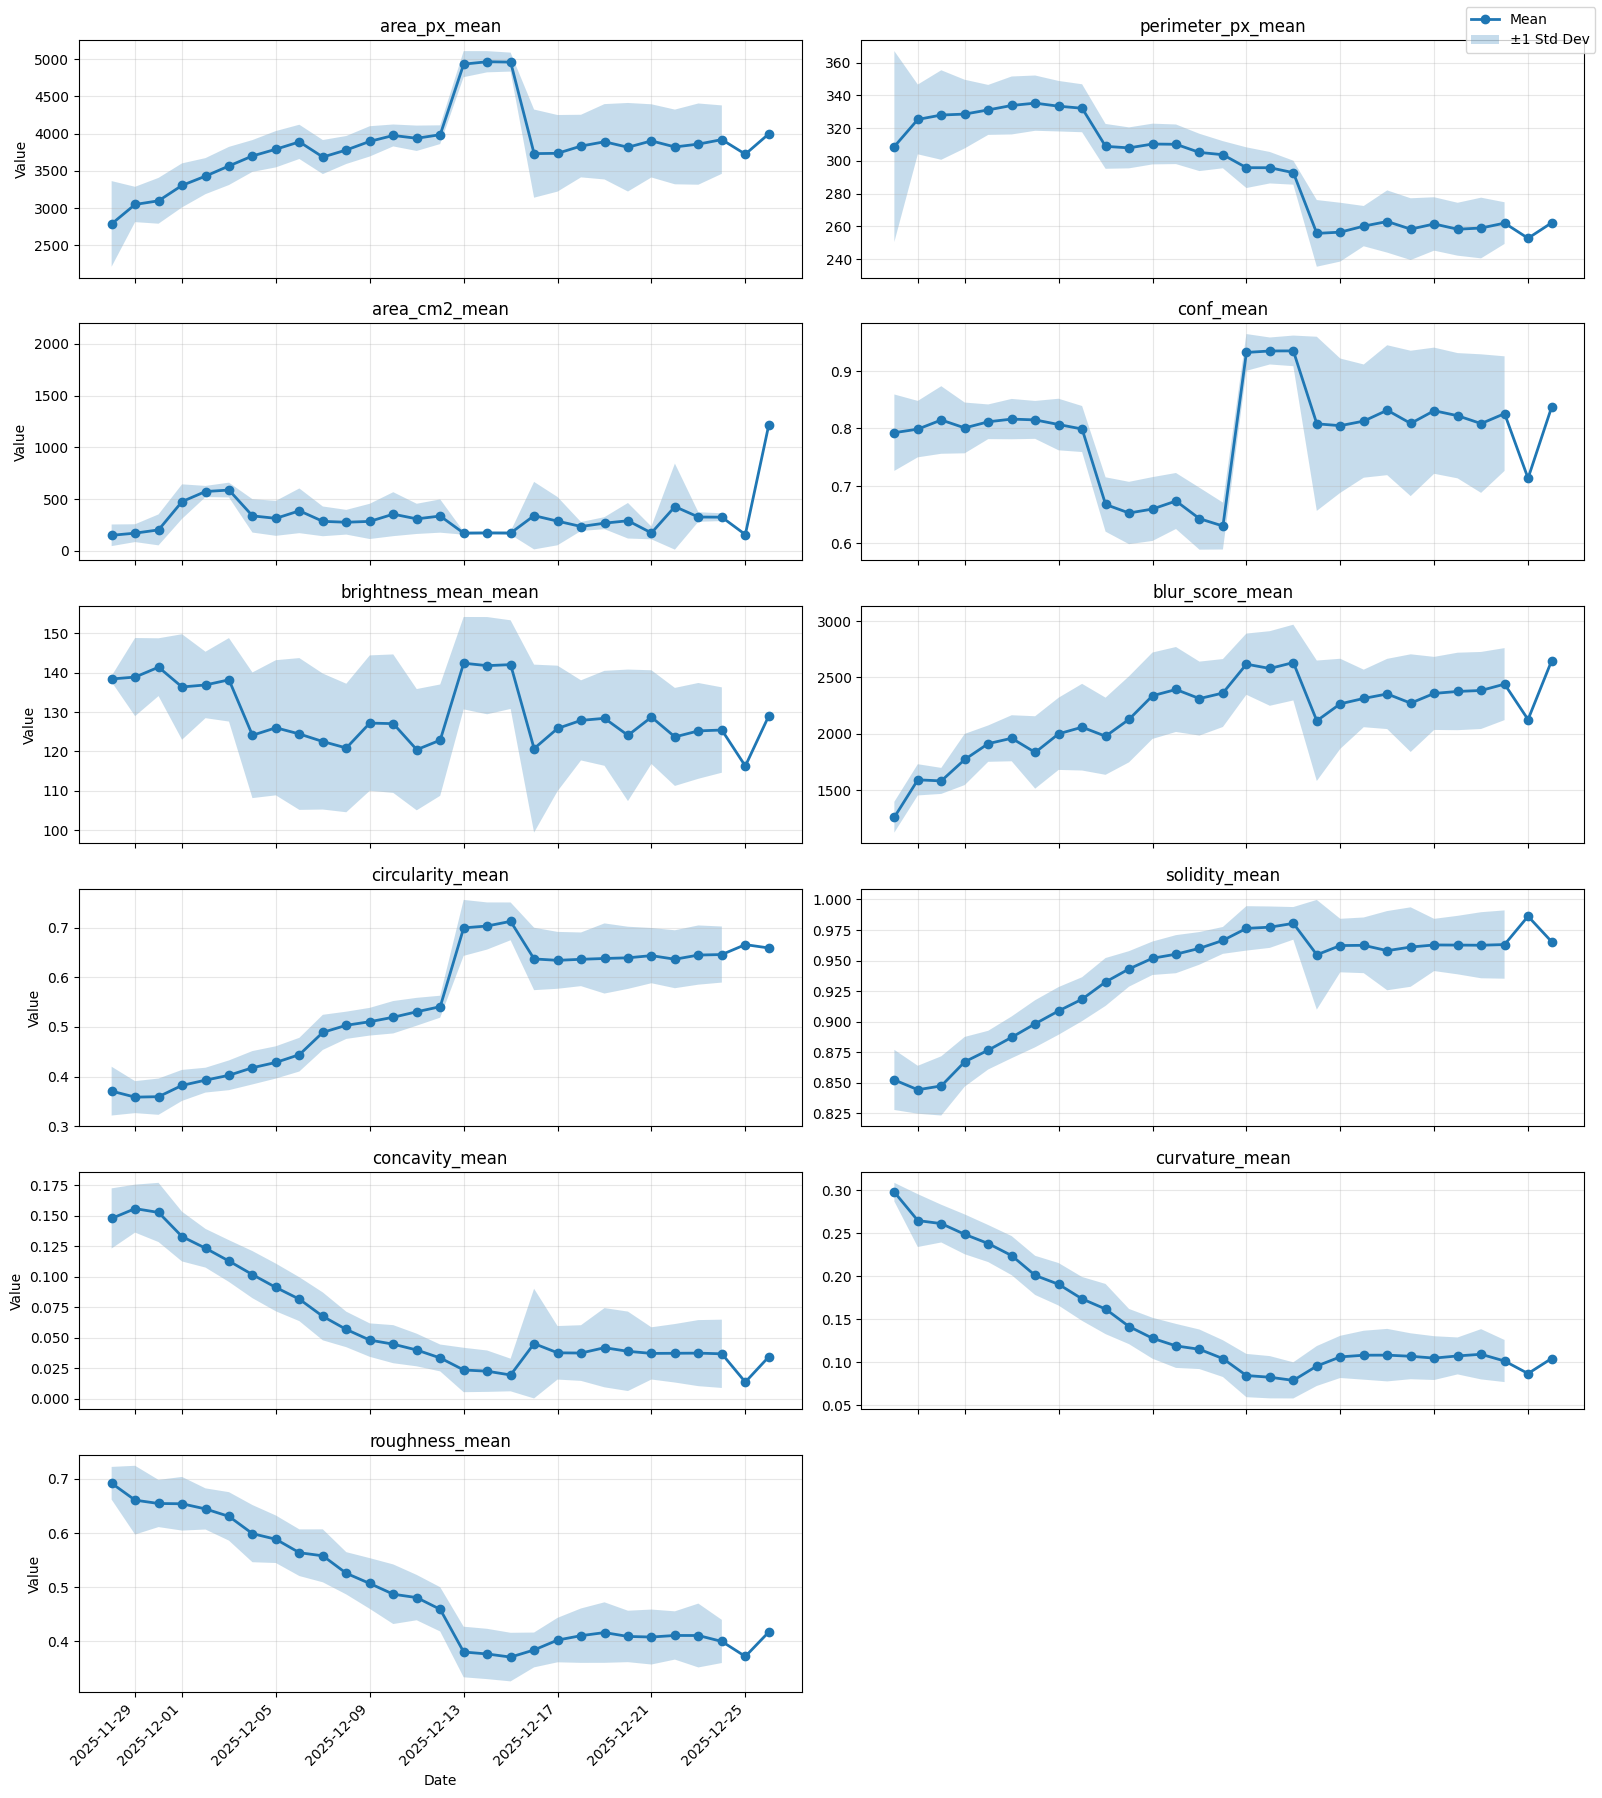

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# bed_date 통계 엑셀을 이용해 10개 지표를 날짜(x) vs 값(y)으로 시각화
# - 캡쳐 그림 스타일: mean 라인 + (가능하면) ±1 std 음영
# - 5x2 서브플롯으로 한 번에 출력
# =========================================================

# ====== 0) 입력 파일 설정 ======
IN_XLSX = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/2파트(251213-251226)/251128-251226 statical index.xlsx"  # 필요 시 수정
SHEET = "Sheet2"  # 이 시트명으로 저장했었음

# ====== 1) 시각화할 컬럼 리스트 ======
columns = [
    'area_px_mean',
    'perimeter_px_mean',
    'area_cm2_mean',
    'conf_mean',
    'brightness_mean_mean',
    'blur_score_mean',
    'circularity_mean',
    'solidity_mean',
    'concavity_mean',
    'curvature_mean',
    'roughness_mean'
]

# ====== 2) 로드 ======
df = pd.read_excel(IN_XLSX, sheet_name=SHEET)

# ====== 3) date_dt 만들기 ======
# date 컬럼이 없으면 bed_date에서 추출 (bed00_YYYYMMDD 형태 가정)
if 'date' not in df.columns:
    if 'bed_date' in df.columns:
        df['date'] = df['bed_date'].astype(str).str.extract(r'_([0-9]{8})$')
    else:
        raise ValueError("엑셀에 'date' 또는 'bed_date' 컬럼이 없습니다.")

# YYYYMMDD -> datetime
df['date_dt'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d', errors='coerce')
if df['date_dt'].isna().all():
    # 혹시 date가 2025-12-06 같은 형태면 자동 파싱
    df['date_dt'] = pd.to_datetime(df['date'].astype(str), errors='coerce')

# 정렬
df = df.sort_values('date_dt').reset_index(drop=True)

# ====== 4) daily(일자 단위)로 재-요약 ======
missing = [c for c in columns if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 시트에 없습니다: {missing}")

for c in columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# daily_mean = 같은 날짜의 bed_date 평균
# daily_std  = 같은 날짜의 bed_date 표준편차(= bed 간 변이)
daily = df.groupby('date_dt')[columns].agg(['mean', 'std']).reset_index()

# MultiIndex 컬럼 펼치기: metric__mean, metric__std
daily.columns = ['date_dt'] + [f"{m}__{s}" for (m, s) in daily.columns[1:]]

# ====== 5) 6x2 플롯 (캡쳐 스타일) ======
fig, axes = plt.subplots(6, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for i, col in enumerate(columns):
    ax = axes[i]

    mcol = f"{col}__mean"
    scol = f"{col}__std"

    x = daily['date_dt']
    y = daily[mcol]

    # Mean line
    ax.plot(x, y, marker='o', linewidth=2, label='Mean')

    # ±1 Std Dev
    if scol in daily.columns:
        s = daily[scol]
        ax.fill_between(x, y - s, y + s, alpha=0.25, label='±1 Std Dev')

    ax.set_title(col)
    ax.grid(True, alpha=0.3)
    if i % 2 == 0:
        ax.set_ylabel('Value')

# 남는 축 숨김(혹시 columns 수가 10이 아닐 때)
for j in range(len(columns), len(axes)):
    axes[j].axis('off')

for ax in axes[-2:]:
    ax.set_xlabel('Date')

# 공통 범례
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right')

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

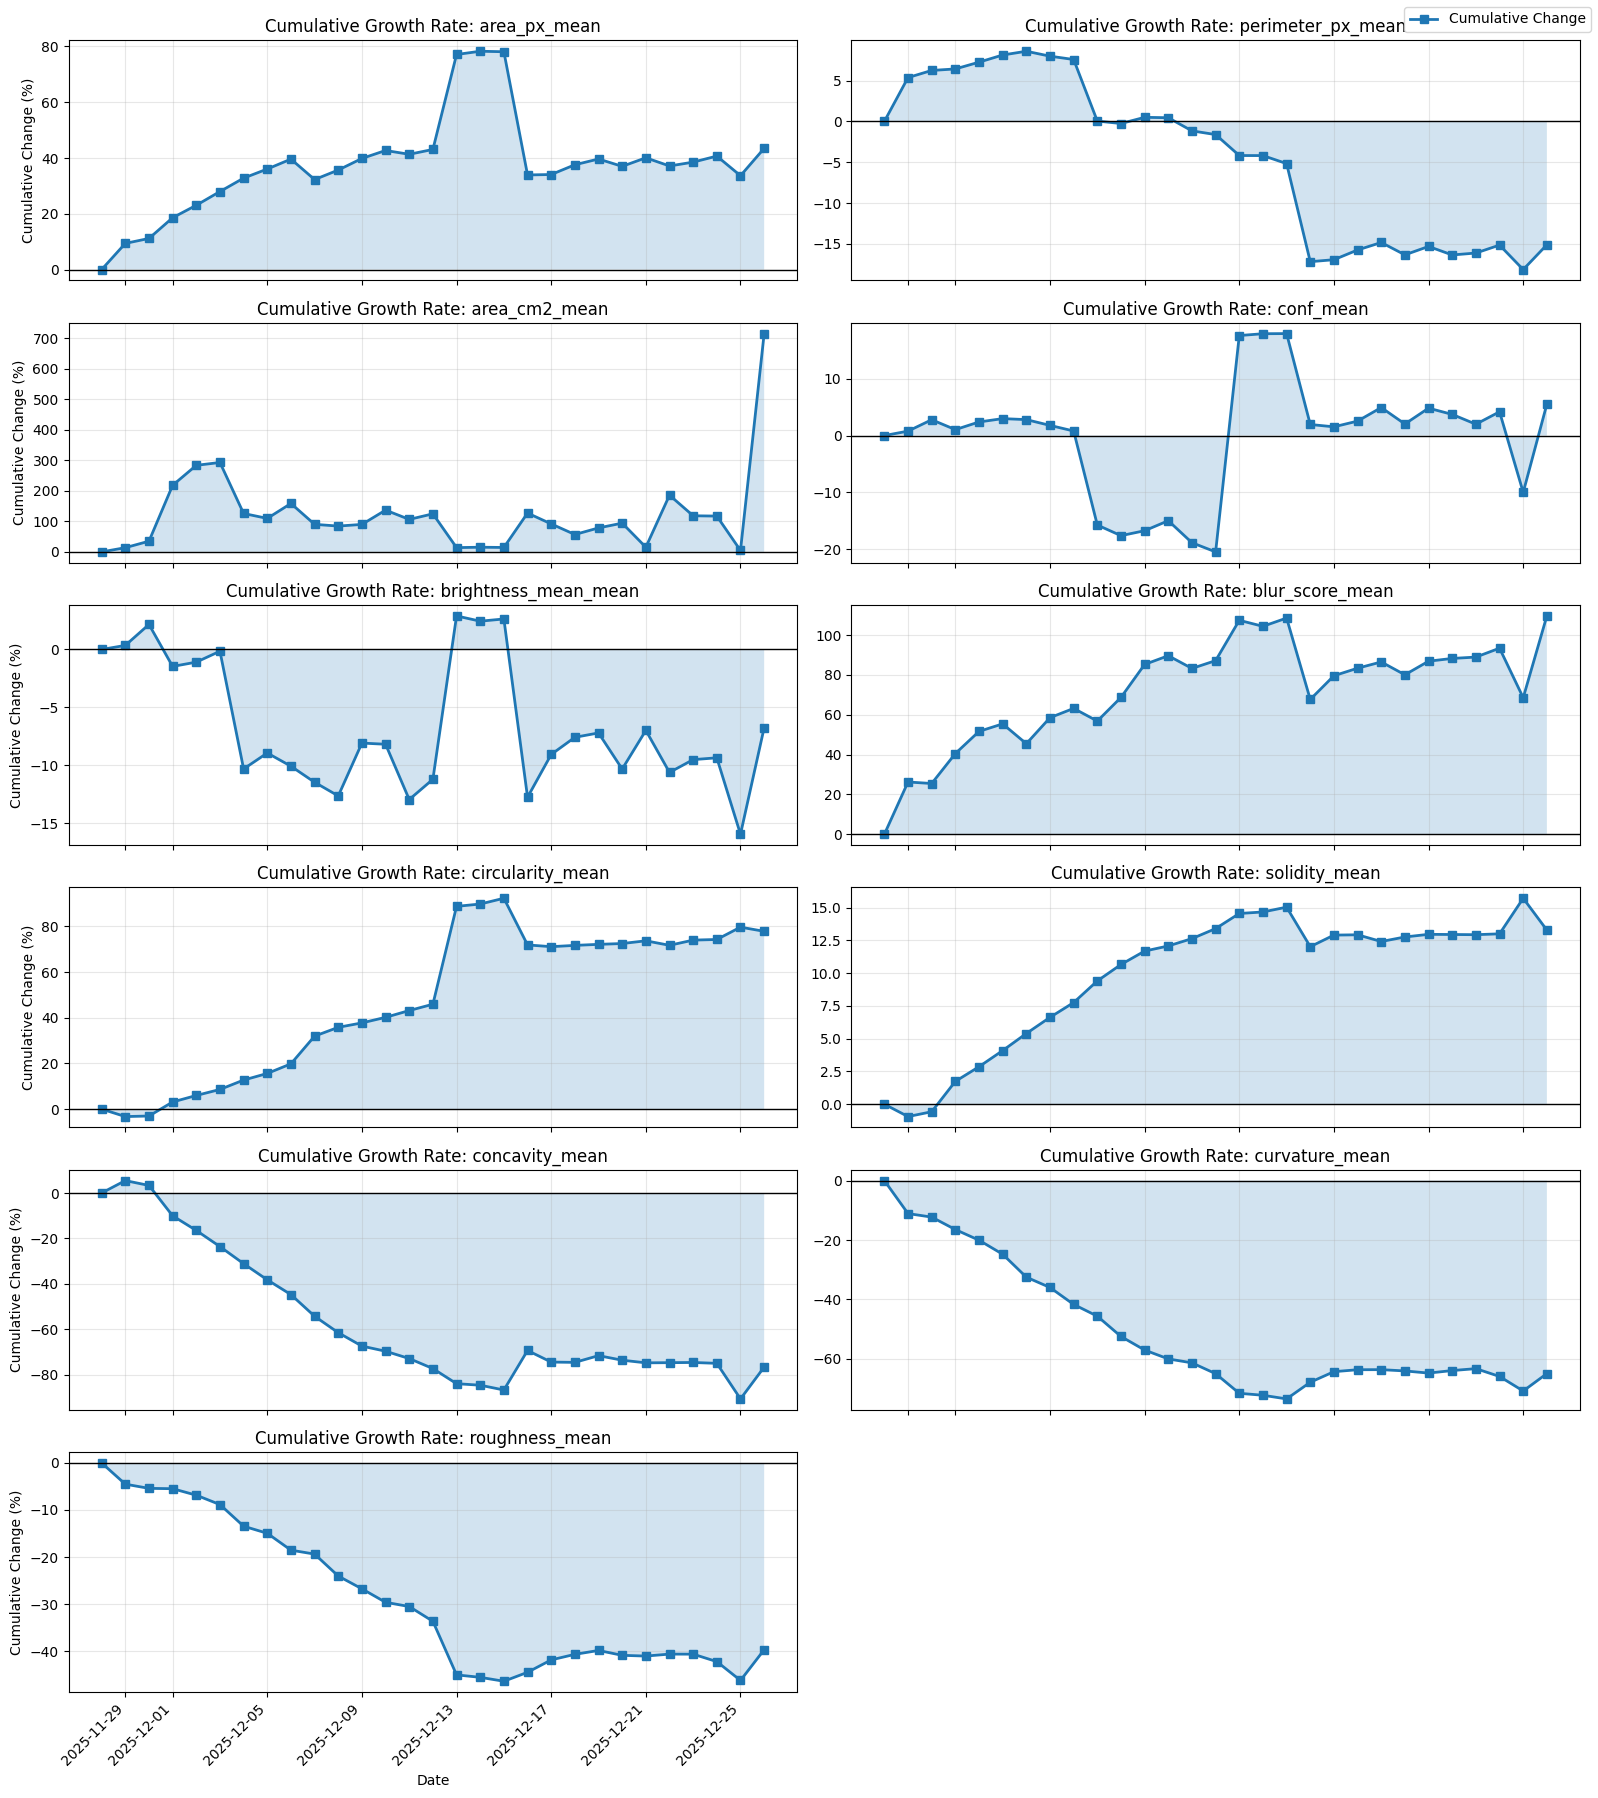

In [12]:
## 누적그래프

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====== 1) 시각화할 컬럼(Mean 컬럼) ======
columns = [
    'area_px_mean',
    'perimeter_px_mean',
    'area_cm2_mean',
    'conf_mean',
    'brightness_mean_mean',
    'blur_score_mean',
    # 'perimeter_px_mean',  <-- Removed duplicate
    'circularity_mean',
    'solidity_mean',
    'concavity_mean',
    'curvature_mean',
    'roughness_mean'
]

# ====== 3) date_dt 만들기 ======
# date 컬럼이 없으면 bed_date에서 추출 (bed00_YYYYMMDD 형태 가정)
if 'date' not in df.columns:
    if 'bed_date' in df.columns:
        df['date'] = df['bed_date'].astype(str).str.extract(r'_([0-9]{8})$')
    else:
        raise ValueError("엑셀에 'date' 또는 'bed_date' 컬럼이 없습니다.")

# YYYYMMDD -> datetime
df['date_dt'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d', errors='coerce')
if df['date_dt'].isna().all():
    # 혹시 date가 2025-12-06 같은 형태면 자동 파싱
    df['date_dt'] = pd.to_datetime(df['date'].astype(str), errors='coerce')

# 정렬
df = df.sort_values('date_dt').reset_index(drop=True)

# ====== 4) daily(일자 단위)로 재-요약 ======
missing = [c for c in columns if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 시트에 없습니다: {missing}")

for c in columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# daily_mean = 같은 날짜의 bed_date 평균
# daily_std  = 같은 날짜의 bed_date 표준편차(= bed 간 변이)
daily = df.groupby('date_dt')[columns].agg(['mean', 'std']).reset_index()

# MultiIndex 컬럼 펼치기: metric__mean, metric__std
daily.columns = ['date_dt'] + [f"{m}__{s}" for (m, s) in daily.columns[1:]]

# ====== 5) 5x2 플롯 (Cumulative Growth Rate 스타일) ======
# - daily 기준으로 누적 변화율(%) 계산
# - cum_change[%] = (현재값 - 첫날값) / 첫날값 * 100
# - line + filled area (0 기준)

fig, axes = plt.subplots(6, 2, figsize=(16, 18), sharex=True) # Adjusted rows to 6 to fit 11 plots if needed, or stick to 5x2 if fitting.
# columns len is 11. 5x2=10 is not enough. Changed to 6x2=12.
axes = axes.flatten()

for i, col in enumerate(columns):
    ax = axes[i]

    mcol = f"{col}__mean"  # daily에서 생성된 mean 컬럼
    if mcol not in daily.columns:
        ax.set_title(f"{col} (missing)")
        ax.axis('off')
        continue

    x = daily['date_dt']
    y = pd.to_numeric(daily[mcol], errors='coerce')

    # 첫날 기준 누적 변화율(%)
    base = y.iloc[0]
    if pd.isna(base) or base == 0:
        cum = np.full(len(y), np.nan)
    else:
        cum = (y - base) / base * 100.0

    # (4) Cumulative Growth Rate: line + filled area
    ax.plot(x, cum, marker='s', linewidth=2, label='Cumulative Change')
    ax.fill_between(x, cum, 0, alpha=0.2)
    ax.axhline(0, color='black', linewidth=1)

    ax.set_title(f"Cumulative Growth Rate: {col}")
    ax.grid(True, alpha=0.3)

    if i % 2 == 0:
        ax.set_ylabel('Cumulative Change (%)')

# 남는 축 숨김
for j in range(len(columns), len(axes)):
    axes[j].axis('off')

for ax in axes[-2:]:
    ax.set_xlabel('Date')

# 공통 범례
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right')

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

표로 정리

In [13]:
import numpy as np
import pandas as pd

tmp = df.copy()

# bed 정리
tmp["bed"] = tmp["bed"].astype(int)

# ✅ date 포맷이 YYYYMMDD든 2025-12-04든 섞여 있어도 자동 파싱
tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")

# 혹시 파싱 실패가 있으면 확인
if tmp["date"].isna().any():
    bad = tmp[tmp["date"].isna()]
    print(f"[경고] date 파싱 실패 {len(bad)}개. 예시:", bad["date"].head(5).tolist())

tmp = tmp.sort_values(["bed", "date"])

In [14]:


# Ensure 'date' column is correctly parsed for calculations.
# This re-parses the date from 'bed_date' to correct any previous parsing errors.
tmp["date"] = tmp["bed_date"].astype(str).str.extract(r'_([0-9]{8})$')
tmp["date"] = pd.to_datetime(tmp["date"], format='%Y%m%d', errors='coerce')

# =========================
# 1) 날짜 start -> end 성장률
# =========================
start = tmp.loc[tmp.groupby("bed")["date"].idxmin(), ["bed", "date", "area_cm2_mean"]].rename(
    columns={"date": "start_date", "area_cm2_mean": "start_mean_cm2"}
)
end = tmp.loc[tmp.groupby("bed")["date"].idxmax(), ["bed", "date", "area_cm2_mean"]].rename(
    columns={"date": "end_date", "area_cm2_mean": "end_mean_cm2"}
)

date_growth = start.merge(end, on="bed", how="inner")
date_growth["date_range"] = (
    date_growth["start_date"].dt.strftime("%Y-%m-%d")
    + " ~ "
    + date_growth["end_date"].dt.strftime("%Y-%m-%d")
)
date_growth["date_days"] = (date_growth["end_date"] - date_growth["start_date"]).dt.days

date_growth["growth_start_end_%"] = np.where(
    date_growth["start_mean_cm2"] > 0,
    (date_growth["end_mean_cm2"] / date_growth["start_mean_cm2"] - 1) * 100,
    np.nan
)

# =========================
# 2) mean_mm2 min -> max 성장률
# =========================
minv = tmp.groupby("bed")["area_cm2_mean"].min().rename("min_mean_cm2")
maxv = tmp.groupby("bed")["area_cm2_mean"].max().rename("max_mean_cm2")
minmax = pd.concat([minv, maxv], axis=1).reset_index()

minmax["growth_min_max_%"] = np.where(
    minmax["min_mean_cm2"] > 0,
    (minmax["max_mean_cm2"] / minmax["min_mean_cm2"] - 1) * 100,
    np.nan
)

# =========================
# 3) 합쳐서 최종 표 만들기
# =========================
summary = (
    date_growth[["bed", "date_range", "date_days", "start_mean_cm2", "end_mean_cm2", "growth_start_end_%"]]
    .merge(minmax[["bed", "min_mean_cm2", "max_mean_cm2", "growth_min_max_%"]], on="bed", how="left")
    .sort_values("bed")
    .reset_index(drop=True)
)

# 보기 좋게 반올림
summary["start_mean_cm2"] = summary["start_mean_cm2"].round(2)
summary["end_mean_cm2"] = summary["end_mean_cm2"].round(2)
summary["min_mean_cm2"] = summary["min_mean_cm2"].round(2)
summary["max_mean_cm2"] = summary["max_mean_cm2"].round(2)
summary["growth_start_end_%"] = summary["growth_start_end_%"].round(2)
summary["growth_min_max_%"] = summary["growth_min_max_%"].round(2)

summary.head(20)
summary.to_csv("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/2파트(251213-251226)/251226_bed_growth_summary1.csv", index=False, encoding="utf-8-sig")


bed_keep 표시

In [15]:
import pandas as pd
import re

# ==============================
# 설정
# ==============================
INPUT_XLSX = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/2파트(251213-251226)/251226_lettuce_segmentation_area(1)_index.xlsx"
OUTPUT_XLSX = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/1작기(251128-251226)/2파트(251213-251226)/251226_lettuce_segmentation_area(2)_index.xlsx"

bed_keep_list = [84, 44, 7, 57, 4, 29, 94, 64, 12, 55]

# ==============================
# 엑셀 로드
# ==============================
df = pd.read_excel(INPUT_XLSX, sheet_name="Sheet1")

# ==============================
# bed 번호 추출
# ==============================
# filename 또는 bed_date 중 존재하는 컬럼 사용
if "bed_date" in df.columns:
    src = df["bed_date"].astype(str)
elif "filename" in df.columns:
    src = df["filename"].astype(str)
else:
    raise ValueError("bed_date 또는 filename 컬럼이 필요합니다.")

def extract_bed(x):
    m = re.search(r"bed(\d+)", x)
    return int(m.group(1)) if m else None

df["_bed_num"] = src.apply(extract_bed)

# ==============================
# bed_keep 갱신
# ==============================
df["bed_keep"] = df["_bed_num"].apply(
    lambda x: "ㅇ" if x in bed_keep_list else "X"
)

# ==============================
# 정리 및 저장
# ==============================
df = df.drop(columns=["_bed_num"])

df.to_excel(OUTPUT_XLSX, index=False)

print("완료")
print("선택된 bed 수:", (df["bed_keep"] == "ㅇ").sum())


완료
선택된 bed 수: 338
